## Setup: Import Libraries

This notebook uses `duckdb` as its analytical database engine and `pandas` for displaying
query results as DataFrames. DuckDB is an embeddable OLAP database. No server setup required.

In [1]:
import duckdb
import pandas as pd

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.2


## Step 1: Load Data into DuckDB

This project loads the OULAD `studentVle.csv` interaction log into a persistent DuckDB
database file. DuckDB automatically infers column types from the CSV and stores
the data in **columnar format**. Each column is stored contiguously on disk,
separate from other columns.

The table has 6 columns: `code_module`, `code_presentation`, `id_student`,
`id_site`, `date`, and `sum_click`.

In [2]:
DATA_DIR = "/Users/rosiexiumacstudio/Library/CloudStorage/OneDrive-UniversityofSouthernCalifornia/2026/School/Spring 2026/DSCI 551/project/data/archive"

# Create a persistent local DuckDB database file
con = duckdb.connect(f"{DATA_DIR}/../../oulad.db")

# Load studentVle.csv into a DuckDB table using columnar storage
con.execute("""
    CREATE TABLE IF NOT EXISTS student_vle AS 
    SELECT * FROM read_csv_auto(?)
""", [f"{DATA_DIR}/studentVle.csv"])

print("✅ Table created successfully")
con.execute("DESCRIBE student_vle").df()

✅ Table created successfully


,column_name,column_type,null,key,default,extra
0,code_module,VARCHAR,YES,None,None,None
1,code_presentation,VARCHAR,YES,None,None,None
2,id_student,BIGINT,YES,None,None,None
3,id_site,BIGINT,YES,None,None,None
4,date,BIGINT,YES,None,None,None
5,sum_click,BIGINT,YES,None,None,None


In [9]:
# Basic dataset exploration
# Understanding the data before running analytics queries

print("=== Dataset Overview ===")
print(f"Total records: {con.execute('SELECT COUNT(*) FROM student_vle').fetchone()[0]:,}")
print(f"Unique students: {con.execute('SELECT COUNT(DISTINCT id_student) FROM student_vle').fetchone()[0]:,}")
print(f"Unique modules: {con.execute('SELECT COUNT(DISTINCT code_module) FROM student_vle').fetchone()[0]:,}")
print(f"Unique activity sites: {con.execute('SELECT COUNT(DISTINCT id_site) FROM student_vle').fetchone()[0]:,}")
print(f"Date range: day {con.execute('SELECT MIN(date) FROM student_vle').fetchone()[0]} to day {con.execute('SELECT MAX(date) FROM student_vle').fetchone()[0]}")
print(f"Click range: {con.execute('SELECT MIN(sum_click) FROM student_vle').fetchone()[0]} to {con.execute('SELECT MAX(sum_click) FROM student_vle').fetchone()[0]}")

=== Dataset Overview ===
Total records: 10,655,280
Unique students: 26,074
Unique modules: 7
Unique activity sites: 6,268
Date range: day -25 to day 269
Click range: 1 to 6977


## Step 2: Inspect the Dataset

This cell verifies the data loaded correctly and checks the total row count.
This dataset contains over **10 million student interaction records** from
The Open University, making it a realistic large-scale educational analytics workload.

## Query 1: Weekly Activity Summary

**Application behavior:** A learning analytics dashboard needs to show total
student engagement per day across the entire course period.

**DuckDB internal behavior:** DuckDB performs a Sequential Scan (`SEQ_SCAN`)
but only reads the `date` and `sum_click` columns from disk. The remaining 4
columns (`code_module`, `code_presentation`, `id_student`, `id_site`) are
never accessed. This is called **column pruning**.

**Why it matters:** In a row-based database like MySQL, every full row must be
read even when only 2 of 6 columns are needed. DuckDB's columnar storage
reduces I/O by ~67% for this query.

In [3]:
# Query 1: Total clicks per week (day)
# Internally: DuckDB scans ONLY 'date' and 'sum_click' columns — 4 other columns never touched
q1 = con.execute("""
    SELECT date AS day, SUM(sum_click) AS total_clicks
    FROM student_vle
    GROUP BY date
    ORDER BY day
""").df()

print(f"Rows returned: {len(q1)}")
q1.head(10)

Rows returned: 295


,day,total_clicks
0,-25,13879.0
1,-24,14494.0
2,-23,9292.0
3,-22,5633.0
4,-21,3487.0
5,-20,4465.0
6,-19,5373.0
7,-18,174678.0
8,-17,92843.0
9,-16,86519.0


## Query 2: Module-Level Average Engagement

**Application behavior:** Educators want to compare average student click 
activity across different course modules to identify which modules drive 
higher engagement.

**DuckDB internal behavior:** DuckDB scans only `code_module` and `sum_click` 
columns, then applies a `PERFECT_HASH_GROUP_BY`, an optimized in-memory 
hash aggregation that processes data in vectorized batches of 1,024 values, 
keeping computation cache-friendly.

**Why it matters:** Vectorized execution means DuckDB processes a batch of 
1,024 values in a single CPU operation rather than row-by-row, significantly 
reducing computation time on large datasets.

In [4]:
# Query 2: Average clicks per module
# Internally: DuckDB scans ONLY 'code_module' and 'sum_click' columns
q2 = con.execute("""
    SELECT code_module, AVG(sum_click) AS avg_clicks, COUNT(*) AS total_records
    FROM student_vle
    GROUP BY code_module
    ORDER BY avg_clicks DESC
""").df()

q2

,code_module,avg_clicks,total_records
0,FFF,4.382595,4014499
1,EEE,4.144051,961433
2,CCC,3.876506,1207827
3,AAA,3.558833,350298
4,GGG,3.445189,387173
5,BBB,3.339051,1567564
6,DDD,2.552562,2166486


## Query 3: Top Activity Sites by Total Clicks

**Application behavior:** Platform designers want to identify which learning 
activity types (represented by site IDs) receive the most total engagement, 
to inform content design decisions.

**DuckDB internal behavior:** DuckDB scans only `id_site` and `sum_click` 
columns, applies hash aggregation, then returns the top 20 results. Only 
2 of 6 columns are read from disk.

**Why it matters:** This query pattern, scan a subset of columns, aggregate, 
rank, is the most common pattern in learning analytics dashboards. DuckDB's 
columnar architecture is purpose-built for exactly this workload.

In [5]:
# Query 3: Most visited activity sites
# Internally: DuckDB scans ONLY 'id_site' and 'sum_click' columns
q3 = con.execute("""
    SELECT id_site, COUNT(*) AS visit_count, SUM(sum_click) AS total_clicks
    FROM student_vle
    GROUP BY id_site
    ORDER BY total_clicks DESC
    LIMIT 20
""").df()

q3


,id_site,visit_count,total_clicks
0,716238,156399,718737.0
1,882537,157590,716869.0
2,526721,122408,586632.0
3,673519,120291,455896.0
4,909013,126527,442887.0
5,716216,139057,438037.0
6,542807,60316,420908.0
7,779089,90574,396097.0
8,882545,132508,390011.0
9,547303,88243,375155.0


## Internals Deep Dive: Query Execution Plan (EXPLAIN)

This cell uses DuckDB's `EXPLAIN` command to inspect the physical execution plan for
Query 1. This directly reveals the internal behavior of columnar storage.

Key things to look for in the output:
- `SEQ_SCAN` — DuckDB performs a sequential scan of the table
- `Projections: date | sum_click` — **only these 2 columns are read from disk**
- `~10,655,280 rows` — confirms the full dataset is being processed
- `PERFECT_HASH_GROUP_BY` — optimized hash aggregation operator

This is the core evidence that columnar storage enables column pruning:
4 out of 6 columns are completely skipped during query execution.

In [6]:
# Show DuckDB's execution plan this is the core of internals mapping
# Look for: SEQ_SCAN with Projections showing only the columns actually read

plan = con.execute("""
    EXPLAIN 
    SELECT date, SUM(sum_click) AS total_clicks
    FROM student_vle
    GROUP BY date
    ORDER BY date
""").df()

print(plan.to_string())

     explain_key                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## Visualization: Analytical Query Results

This notebook visualizes the results of Query 1 and Query 2 to demonstrate the
end-to-end workflow: raw interaction logs → DuckDB aggregation →
actionable educational insights.

These charts represent the kind of output a real learning analytics
dashboard would surface for instructors and course designers.

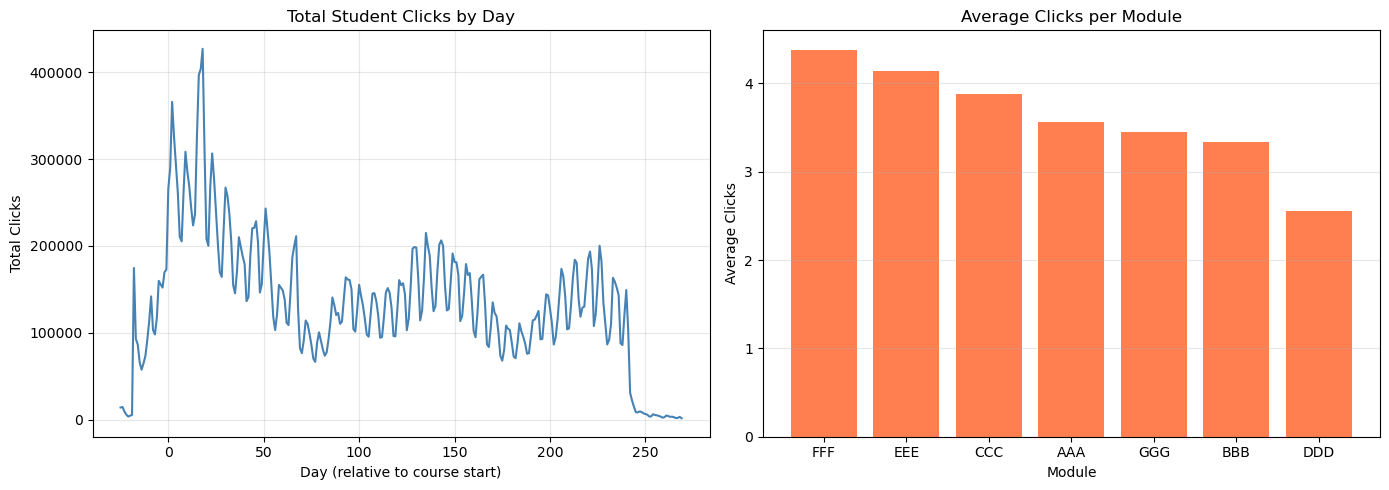

Chart saved.


In [7]:
import matplotlib.pyplot as plt

# Plot weekly click trends — shows real educational analytics use case
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Weekly activity trend
axes[0].plot(q1['day'], q1['total_clicks'], color='steelblue', linewidth=1.5)
axes[0].set_title('Total Student Clicks by Day')
axes[0].set_xlabel('Day (relative to course start)')
axes[0].set_ylabel('Total Clicks')
axes[0].grid(True, alpha=0.3)

# Right: Average engagement by module
axes[1].bar(q2['code_module'], q2['avg_clicks'], color='coral')
axes[1].set_title('Average Clicks per Module')
axes[1].set_xlabel('Module')
axes[1].set_ylabel('Average Clicks')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('oulad_analytics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [8]:
# Internals Summary
# Summary: mapping application behavior to DuckDB internals
summary = {
    "Query": [
        "Weekly activity summary",
        "Module-level engagement",
        "Top activity sites"
    ],
    "Columns Scanned": [
        "date, sum_click (2/6)",
        "code_module, sum_click (2/6)",
        "id_site, sum_click (2/6)"
    ],
    "DuckDB Internal Behavior": [
        "SEQ_SCAN with column pruning, vectorized aggregation",
        "SEQ_SCAN with column pruning, PERFECT_HASH_GROUP_BY",
        "SEQ_SCAN with column pruning, hash aggregation"
    ],
    "Why It Matters": [
        "67% less I/O vs row-based DB",
        "67% less I/O vs row-based DB",
        "67% less I/O vs row-based DB"
    ]
}

pd.DataFrame(summary)

,Query,Columns Scanned,DuckDB Internal Behavior,Why It Matters
0,Weekly activity summary,"date, sum_click (2/6)","SEQ_SCAN with column pruning, vectorized aggre...",67% less I/O vs row-based DB
1,Module-level engagement,"code_module, sum_click (2/6)","SEQ_SCAN with column pruning, PERFECT_HASH_GRO...",67% less I/O vs row-based DB
2,Top activity sites,"id_site, sum_click (2/6)","SEQ_SCAN with column pruning, hash aggregation",67% less I/O vs row-based DB
